# HMLR Property Price Analysis

An analysis of UK residential property transaction data using HM Land Registry's publicly available Price Paid Dataset.

## Objectives
1. **Exploratory Data Analysis** — understand price distributions, transaction volumes, and patterns across property types, regions, and time
2. **Hypothesis Testing** — apply statistical tests to investigate whether observed differences in property prices are statistically significant
3. **AutoML Classification** — use PyCaret to build and compare models predicting property price band from transaction features

## Data Source
HM Land Registry Price Paid Data — publicly available under the [Open Government Licence](https://www.nationalarchives.gov.uk/doc/open-government-licence/version/3/).  
Coverage: residential property sales in England and Wales registered with HMLR.  
This notebook downloads and analyses data for 2024 and 2025.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 2. Data Download

The Price Paid Dataset is published by HMLR and freely available. Each annual file contains all residential property transactions registered that year in England and Wales.

The dataset has no header row — column names are added manually based on the HMLR data specification (https://www.gov.uk/guidance/about-the-price-paid-data#download-option).

In [2]:
COLUMNS = [
    'transaction_id', 'price', 'date_of_transfer', 'postcode',
    'property_type', 'old_new', 'duration', 'paon', 'saon',
    'street', 'locality', 'town_city', 'district', 'county',
    'ppd_category', 'record_status'
]

YEARS = [2024, 2025]
BASE_URL = 'http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-{year}.csv'

os.makedirs('data', exist_ok=True)

for year in YEARS:
    filepath = f'data/pp-{year}.csv'
    if not os.path.exists(filepath):
        print(f'Downloading {year} Price Paid Data...')
        urllib.request.urlretrieve(BASE_URL.format(year=year), filepath)
        print(f'{year} download complete.')
    else:
        print(f'{year} data already present.')

2024 data already present.
2025 data already present.


## 3. Load and Clean Data

In [3]:
dfs = []
for year in YEARS:
    df_year = pd.read_csv(f'data/pp-{year}.csv', header=None, names=COLUMNS, low_memory=False)
    dfs.append(df_year)

df = pd.concat(dfs, ignore_index=True)

print(f'Total records: {len(df):,}')
df.head()

Total records: 1,726,490


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
0,{2131FCF5-B031-86E8-E063-4804A8C0372B},320000,2024-07-26 00:00,MK40 3SG,T,N,F,38,NaN,GEORGE STREET,NaN,BEDFORD,BEDFORD,BEDFORD,A,A
1,{2131FCF5-B034-86E8-E063-4804A8C0372B},300000,2024-02-15 00:00,MK43 9GH,S,N,F,12,NaN,BRICK CRESCENT,STEWARTBY,BEDFORD,BEDFORD,BEDFORD,A,A
2,{2131FCF5-B036-86E8-E063-4804A8C0372B},470000,2024-08-21 00:00,MK45 2BF,S,N,F,21,NaN,COLTSFOOT CORNER,AMPTHILL,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
3,{2131FCF5-B037-86E8-E063-4804A8C0372B},527500,2024-07-29 00:00,MK43 0YX,D,N,L,1,NaN,FALLOWS CRESCENT,CRANFIELD,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
4,{2131FCF5-B038-86E8-E063-4804A8C0372B},351000,2024-07-17 00:00,LU3 3AR,T,N,F,320,NaN,SUNDON PARK ROAD,NaN,LUTON,LUTON,LUTON,A,A


In [4]:
# Parse dates and extract time features
df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'])
df['year'] = df['date_of_transfer'].dt.year
df['month'] = df['date_of_transfer'].dt.month
df['quarter'] = df['date_of_transfer'].dt.quarter

# Filter to standard residential transactions only (PPD category A)
df = df[df['ppd_category'] == 'A'].copy()

# Filter to standard property types (exclude 'O' - Other)
df = df[df['property_type'].isin(['D', 'S', 'T', 'F'])].copy()

# Filter to remove unrealistic prices that are likely outliers
df = df[(df['price'] >= 10_000) & (df['price'] <= 10_000_000)].copy()

print(f'Records after cleaning: {len(df):,}')
print(f'\nDate range: {df["date_of_transfer"].min().date()} to {df["date_of_transfer"].max().date()}')
print(f'\nNull values:')
print(df[['price', 'property_type', 'old_new', 'duration', 'county', 'town_city']].isnull().sum())

Records after cleaning: 1,445,776

Date range: 2024-01-01 to 2025-12-31

Null values:
price            0
property_type    0
old_new          0
duration         0
county           0
town_city        0
dtype: int64


In [5]:
# Map coded values to readable labels
property_type_map = {'D': 'Detached', 'S': 'Semi-Detached', 'T': 'Terraced', 'F': 'Flat'}
old_new_map = {'Y': 'New Build', 'N': 'Established'}
duration_map = {'F': 'Freehold', 'L': 'Leasehold'}

df['property_type_label'] = df['property_type'].map(property_type_map)
df['old_new_label'] = df['old_new'].map(old_new_map)
df['duration_label'] = df['duration'].map(duration_map)

df[['price', 'property_type_label', 'old_new_label', 'duration_label', 'county', 'year']].head(10)

,price,property_type_label,old_new_label,duration_label,county,year
0,320000,Terraced,Established,Freehold,BEDFORD,2024
1,300000,Semi-Detached,Established,Freehold,BEDFORD,2024
2,470000,Semi-Detached,Established,Freehold,CENTRAL BEDFORDSHIRE,2024
3,527500,Detached,Established,Leasehold,CENTRAL BEDFORDSHIRE,2024
4,351000,Terraced,Established,Freehold,LUTON,2024
5,395000,Detached,Established,Freehold,CENTRAL BEDFORDSHIRE,2024
6,310000,Semi-Detached,Established,Freehold,BEDFORD,2024
7,435000,Semi-Detached,Established,Freehold,CENTRAL BEDFORDSHIRE,2024
8,435000,Detached,Established,Freehold,CENTRAL BEDFORDSHIRE,2024
9,306000,Semi-Detached,Established,Freehold,CENTRAL BEDFORDSHIRE,2024


## 4. Exploratory Data Analysis

### 4.1 Overall Price Distribution

In [6]:
print('=== Price Summary Statistics ===')
print(df['price'].describe().apply('{:,.0f}'.format))
print(f'\nMedian price: £{df["price"].median():,.0f}')

=== Price Summary Statistics ===
count     1,445,776
mean        365,492
std         319,502
min          10,000
25%         197,950
50%         292,500
75%         432,500
max      10,000,000
Name: price, dtype: object

Median price: £292,500


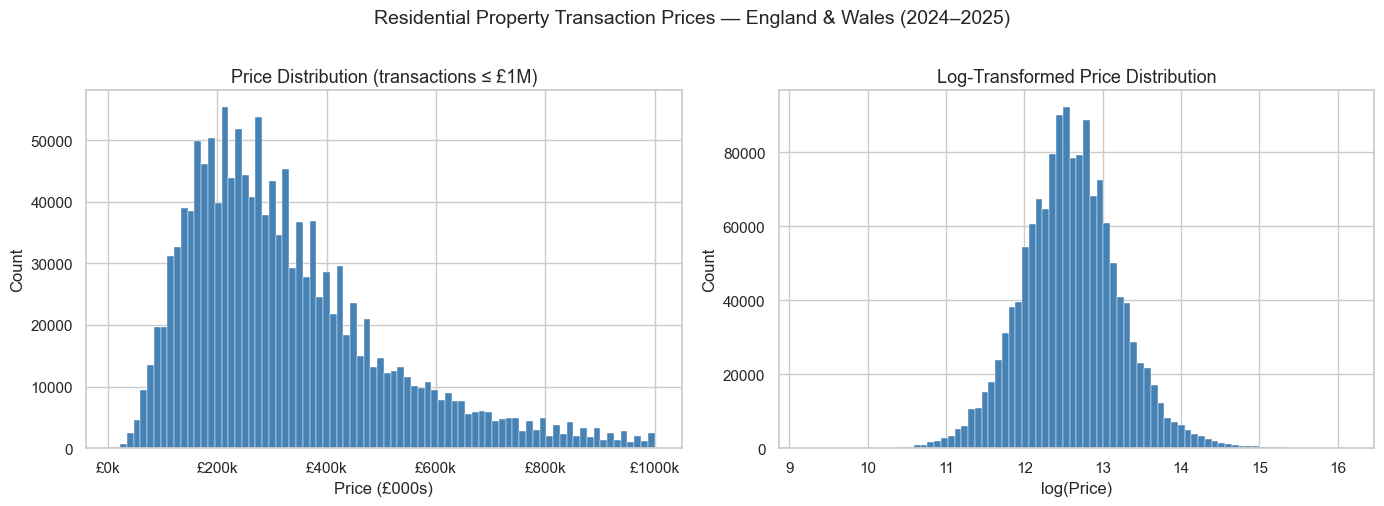


Note: Property prices are right-skewed. Log transformation produces an approximately normal distribution,
which is important for the parametric hypothesis tests applied later.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price distribution (capped at 1M for visibility)
axes[0].hist(df[df['price'] <= 1_000_000]['price'] / 1000, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price Distribution (transactions ≤ £1M)', fontsize=13)
axes[0].set_xlabel('Price (£000s)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}k'))

# Log-transformed price distribution
axes[1].hist(np.log(df['price']), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=13)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Residential Property Transaction Prices — England & Wales (2024–2025)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nNote: Property prices are right-skewed. Log transformation produces an approximately normal distribution,')
print('which is important for the parametric hypothesis tests applied later.')

### 4.2 Transaction Volume Over Time

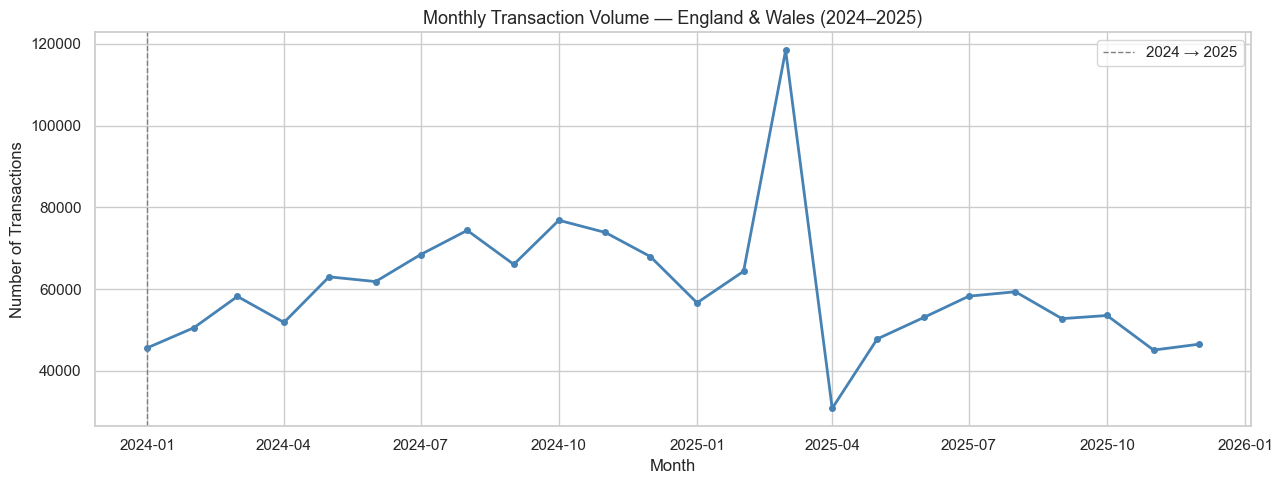

In [8]:
monthly_vol = df.groupby(['year', 'month']).size().reset_index(name='transactions')
monthly_vol['period'] = pd.to_datetime(monthly_vol[['year', 'month']].assign(day=1))

plt.figure(figsize=(13, 5))
plt.plot(monthly_vol['period'], monthly_vol['transactions'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.axvline(pd.Timestamp('2024-01-01'), color='grey', linestyle='--', linewidth=1, label='2024 → 2025')
plt.title('Monthly Transaction Volume — England & Wales (2024–2025)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Prices by Property Type

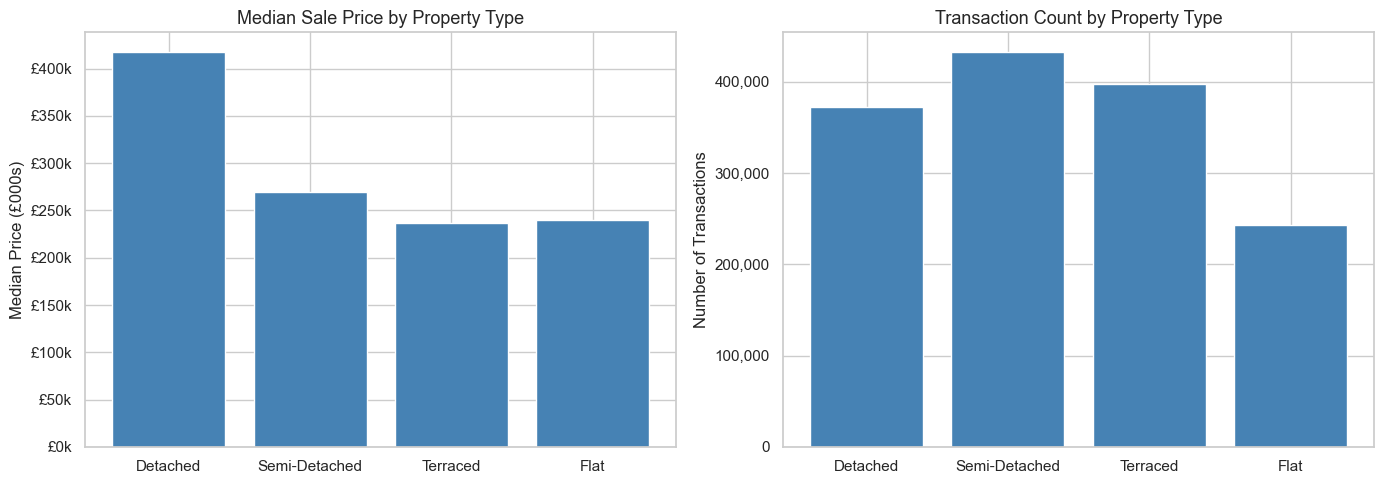


Median prices by property type:
property_type_label
Detached         £417,500
Semi-Detached    £270,000
Terraced         £236,500
Flat             £240,000
Name: price, dtype: object


In [9]:
property_order = ['Detached', 'Semi-Detached', 'Terraced', 'Flat']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median prices by property type
median_by_type = df.groupby('property_type_label')['price'].median().reindex(property_order)
axes[0].bar(median_by_type.index, median_by_type.values / 1000, color='steelblue')
axes[0].set_title('Median Sale Price by Property Type', fontsize=13)
axes[0].set_ylabel('Median Price (£000s)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}k'))

# Transaction count by property type
count_by_type = df['property_type_label'].value_counts().reindex(property_order)
axes[1].bar(count_by_type.index, count_by_type.values, color='steelblue')
axes[1].set_title('Transaction Count by Property Type', fontsize=13)
axes[1].set_ylabel('Number of Transactions')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print('\nMedian prices by property type:')
print(df.groupby('property_type_label')['price'].median().reindex(property_order).apply('£{:,.0f}'.format))

### 4.4 Year-on-Year Comparison (2024 vs 2025)

Year-on-year median price change by property type:
year                     2024      2025 change_pct
property_type_label                               
Detached             £415,000  £420,000      +1.2%
Semi-Detached        £269,000  £275,000      +2.2%
Terraced             £234,995  £240,000      +2.1%
Flat                 £244,950  £235,000      -4.1%


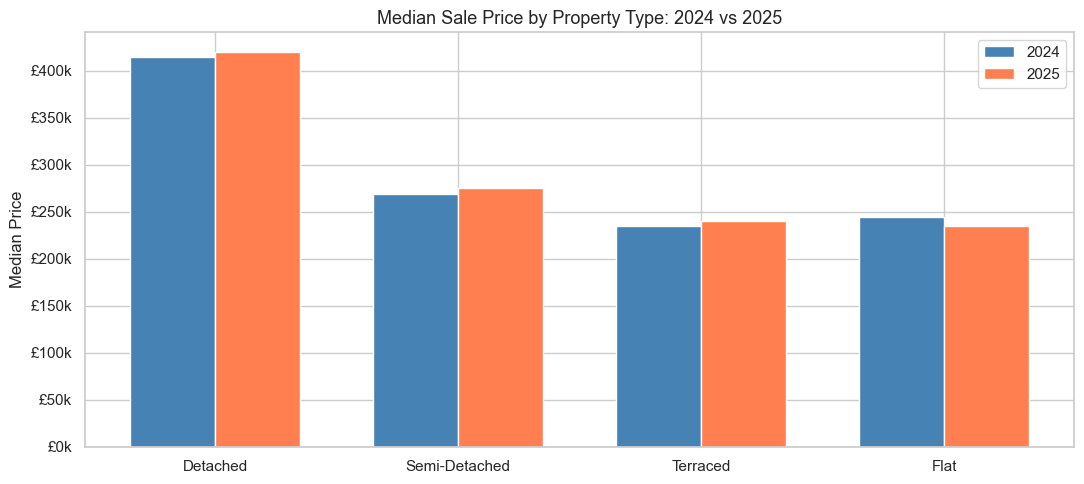

In [10]:
yoy = df.groupby(['year', 'property_type_label'])['price'].median().reset_index()
yoy_pivot = yoy.pivot(index='property_type_label', columns='year', values='price').reindex(property_order)
yoy_pivot['change_pct'] = ((yoy_pivot[2025] - yoy_pivot[2024]) / yoy_pivot[2024]) * 100

print('Year-on-year median price change by property type:')
display_df = yoy_pivot.copy()
display_df[2024] = display_df[2024].apply('£{:,.0f}'.format)
display_df[2025] = display_df[2025].apply('£{:,.0f}'.format)
display_df['change_pct'] = display_df['change_pct'].apply('{:+.1f}%'.format)
print(display_df)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(property_order))
width = 0.35
ax.bar(x - width/2, yoy_pivot[2024] / 1000, width, label='2024', color='steelblue')
ax.bar(x + width/2, yoy_pivot[2025] / 1000, width, label='2025', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(property_order)
ax.set_ylabel('Median Price')
ax.set_title('Median Sale Price by Property Type: 2024 vs 2025', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

### 4.5 New Build vs Established Property

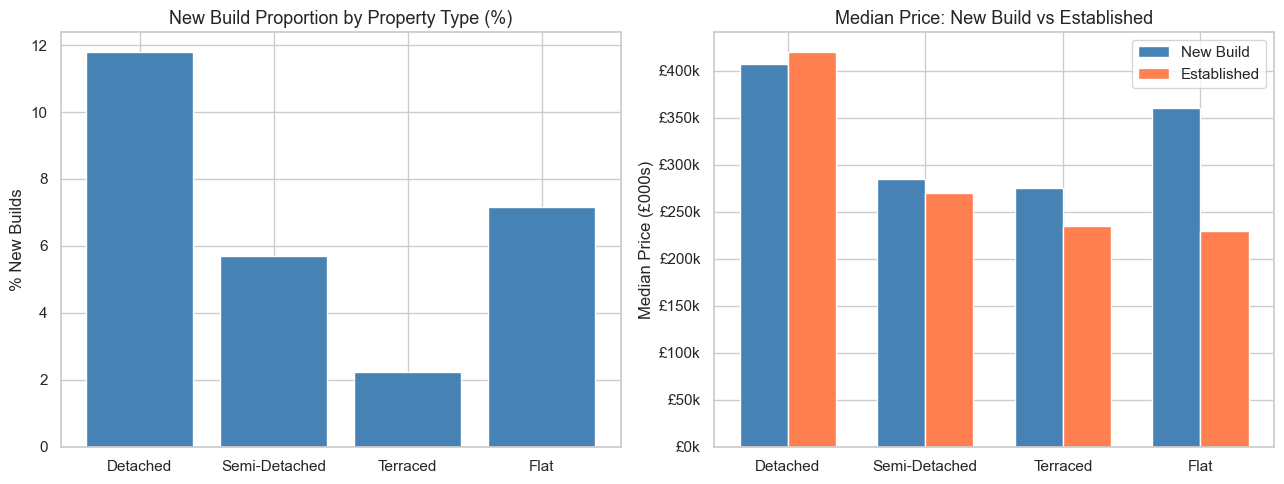

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# New build proportion by property type
new_build_pct = df.groupby('property_type_label')['old_new'].apply(
    lambda x: (x == 'Y').mean() * 100
).reindex(property_order)

axes[0].bar(new_build_pct.index, new_build_pct.values, color='steelblue')
axes[0].set_title('New Build Proportion by Property Type (%)', fontsize=13)
axes[0].set_ylabel('% New Builds')

# Median price: new build vs established, by property type
new_vs_est = df.groupby(['property_type_label', 'old_new_label'])['price'].median().unstack().reindex(property_order)
x = np.arange(len(property_order))
width = 0.35
axes[1].bar(x - width/2, new_vs_est['New Build'] / 1000, width, label='New Build', color='steelblue')
axes[1].bar(x + width/2, new_vs_est['Established'] / 1000, width, label='Established', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(property_order)
axes[1].set_ylabel('Median Price (£000s)')
axes[1].set_title('Median Price: New Build vs Established', fontsize=13)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}k'))
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.6 Top 15 Counties by Median Price and Transaction Volume

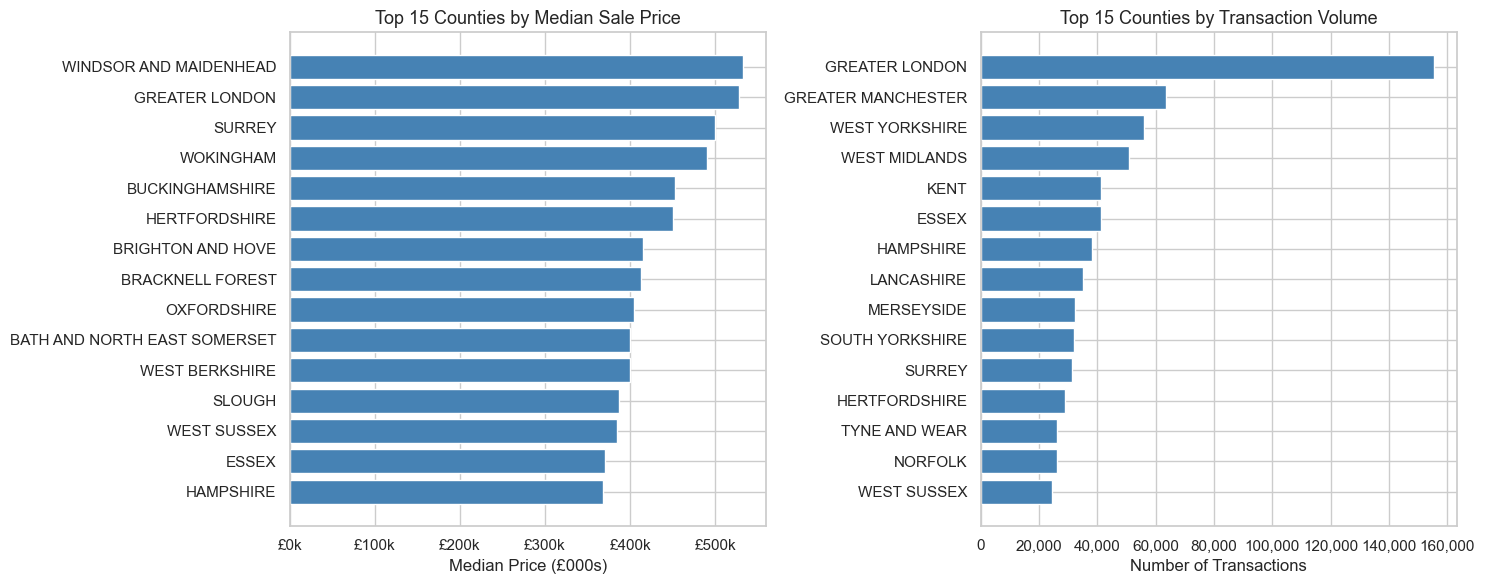

In [12]:
# Limit to counties with at least 500 transactions for reliable medians
county_counts = df['county'].value_counts()
valid_counties = county_counts[county_counts >= 500].index
df_counties = df[df['county'].isin(valid_counties)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 by median price
top_price = df_counties.groupby('county')['price'].median().nlargest(15)
axes[0].barh(top_price.index[::-1], top_price.values[::-1] / 1000, color='steelblue')
axes[0].set_title('Top 15 Counties by Median Sale Price', fontsize=13)
axes[0].set_xlabel('Median Price (£000s)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}k'))

# Top 15 by transaction volume
top_vol = df_counties.groupby('county').size().nlargest(15)
axes[1].barh(top_vol.index[::-1], top_vol.values[::-1], color='steelblue')
axes[1].set_title('Top 15 Counties by Transaction Volume', fontsize=13)
axes[1].set_xlabel('Number of Transactions')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 5. Hypothesis Testing

Property prices are right-skewed, but log-transformed prices are approximately normally distributed (as shown in Section 4.1). I applied statistical tests on log-transformed prices where parametric assumptions apply, and use non-parametric alternatives where appropriate.

Significance level: **α = 0.05** throughout.

### 5.1 Do property prices differ significantly across property types?

**Test:** Kruskal-Wallis H-test (non-parametric one-way ANOVA)  
**Null Hypothesis** The distribution of prices is the same across all property types  
**Alternative Hypothesis** At least one property type has a significantly different price distribution

In [13]:
groups = [df[df['property_type_label'] == pt]['price'].values for pt in property_order]

stat, p_value = stats.kruskal(*groups)

print('Kruskal-Wallis H-test: Property Prices Across Property Types')
print(f'H-statistic: {stat:,.2f}')
print(f'p-value: {p_value:.2e}')
print()
if p_value < 0.05:
    print('Result: Reject H₀. There are statistically significant differences in price distributions across property types (p < 0.05).')
else:
    print('Result: Fail to reject H₀. No statistically significant difference detected.')

print('\nMedian prices for reference:')
for pt in property_order:
    median = df[df['property_type_label'] == pt]['price'].median()
    print(f'  {pt}: £{median:,.0f}')

Kruskal-Wallis H-test: Property Prices Across Property Types
H-statistic: 239,096.88
p-value: 0.00e+00

Result: Reject H₀. There are statistically significant differences in price distributions across property types (p < 0.05).

Median prices for reference:
  Detached: £417,500
  Semi-Detached: £270,000
  Terraced: £236,500
  Flat: £240,000


### 5.2 Did residential property prices change significantly from 2024 to 2025?

**Test:** Independent samples t-test on log-transformed prices  
**H₀:** Mean log(price) in 2024 = mean log(price) in 2024  
**H₁:** Mean log(price) in 2025 ≠ mean log(price) in 2025

In [14]:
prices_2024 = np.log(df[df['year'] == 2024]['price'].values)
prices_2025 = np.log(df[df['year'] == 2025]['price'].values)

stat, p_value = stats.ttest_ind(prices_2024, prices_2025, equal_var=False)  # Welch's t-test

print('Welch\'s Independent Samples t-test: Log(Price) — 2024 vs 2025')
print(f't-statistic: {stat:.4f}')
print(f'p-value: {p_value:.2e}')
print()
if p_value < 0.05:
    print('Result: Reject H₀. There is a statistically significant difference in log(price) between 2024 and 2025.')
else:
    print('Result: Fail to reject H₀.')

print(f'\n2024 median price: £{df[df["year"]==2024]["price"].median():,.0f}')
print(f'2025 median price: £{df[df["year"]==2025]["price"].median():,.0f}')
pct_change = (df[df['year']==2025]['price'].median() - df[df['year']==2024]['price'].median()) / df[df['year']==2024]['price'].median() * 100
print(f'Median price change: {pct_change:+.1f}%')

Welch's Independent Samples t-test: Log(Price) — 2024 vs 2025
t-statistic: -8.4822
p-value: 2.21e-17

Result: Reject H₀. There is a statistically significant difference in log(price) between 2024 and 2025.

2024 median price: £290,000
2025 median price: £295,000
Median price change: +1.7%


### 5.3 Do freehold properties command a significant price premium over leasehold?

**Test:** Mann-Whitney U test (non-parametric, two independent samples)  
**H₀:** The price distribution of freehold and leasehold properties is the same  
**H₁:** Freehold properties have a significantly different price distribution to leasehold

Mann-Whitney U Test: Freehold vs Leasehold Prices
U-statistic: 221,956,870,256
p-value: 0.00e+00

Result: Reject H₀. Freehold and leasehold properties have significantly different price distributions (p < 0.05).

Freehold median price:  £310,000
Leasehold median price: £230,000


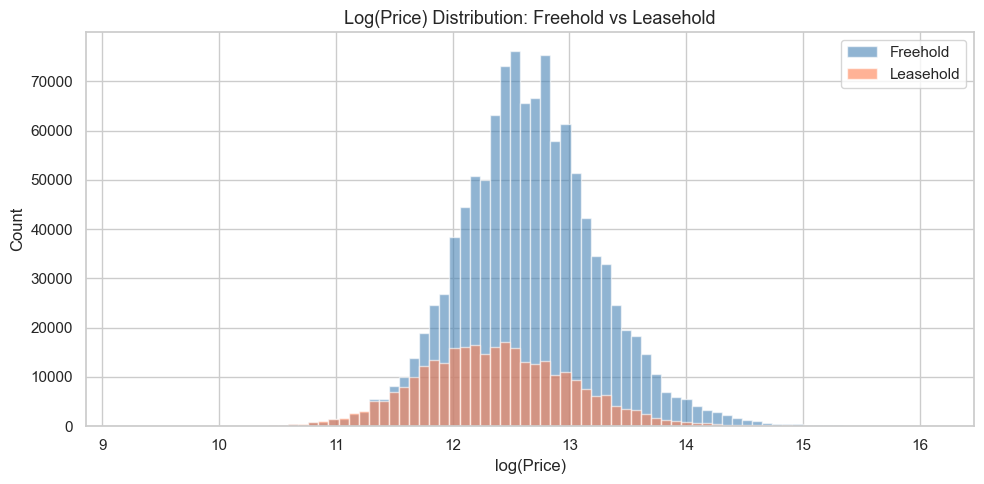

In [15]:
freehold_prices = df[df['duration'] == 'F']['price'].values
leasehold_prices = df[df['duration'] == 'L']['price'].values

stat, p_value = stats.mannwhitneyu(freehold_prices, leasehold_prices, alternative='two-sided')

print('Mann-Whitney U Test: Freehold vs Leasehold Prices')
print(f'U-statistic: {stat:,.0f}')
print(f'p-value: {p_value:.2e}')
print()
if p_value < 0.05:
    print('Result: Reject H₀. Freehold and leasehold properties have significantly different price distributions (p < 0.05).')
else:
    print('Result: Fail to reject H₀.')

print(f'\nFreehold median price:  £{np.median(freehold_prices):,.0f}')
print(f'Leasehold median price: £{np.median(leasehold_prices):,.0f}')

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log(freehold_prices), bins=80, alpha=0.6, label='Freehold', color='steelblue')
ax.hist(np.log(leasehold_prices), bins=80, alpha=0.6, label='Leasehold', color='coral')
ax.set_title('Log(Price) Distribution: Freehold vs Leasehold', fontsize=13)
ax.set_xlabel('log(Price)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Is there an association between property type and new/established build status?

**Test:** Chi-squared test of independence  
**H₀:** Property type and build status (new/established) are independent  
**H₁:** There is a statistically significant association between property type and build status

In [16]:
contingency_table = pd.crosstab(df['property_type_label'], df['old_new_label'])
print('Contingency table (counts):')
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f'\nChi-squared statistic: {chi2:,.2f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value: {p_value:.2e}')
print()
if p_value < 0.05:
    print('Result: Reject H₀. Property type and build status are not independent — there is a significant association.')
else:
    print('Result: Fail to reject H₀.')

print('\nNew build % by property type:')
pct_new = contingency_table['New Build'] / contingency_table['New Build'].sum() * 100
print(pct_new.reindex(property_order).apply('{:.1f}%'.format))

Contingency table (counts):
old_new_label        Established  New Build
property_type_label                        
Detached                  328904      43962
Flat                      225806      17442
Semi-Detached             407920      24647
Terraced                  388203       8892

Chi-squared statistic: 29,378.17
Degrees of freedom: 3
p-value: 0.00e+00

Result: Reject H₀. Property type and build status are not independent — there is a significant association.

New build % by property type:
property_type_label
Detached         46.3%
Semi-Detached    26.0%
Terraced          9.4%
Flat             18.4%
Name: New Build, dtype: object


## 6. Feature Engineering for Machine Learning

Defining the prediction task as classifying transactions into price bands based on national quartiles. This framing reflects a realistic use case: predicting whether a property falls into a low, medium-low, medium-high, or high price segment based on its observable characteristics at the point of registration.

In [17]:
# Define price bands based on quartiles
quartiles = df['price'].quantile([0.25, 0.5, 0.75])
print('Price quartile boundaries:')
print(f'  Q1 (25th percentile): £{quartiles[0.25]:,.0f}')
print(f'  Q2 (50th percentile): £{quartiles[0.50]:,.0f}')
print(f'  Q3 (75th percentile): £{quartiles[0.75]:,.0f}')

def assign_price_band(price):
    if price <= quartiles[0.25]:
        return 'Low'
    elif price <= quartiles[0.50]:
        return 'Medium-Low'
    elif price <= quartiles[0.75]:
        return 'Medium-High'
    else:
        return 'High'

df['price_band'] = df['price'].apply(assign_price_band)

print('\nPrice band distribution:')
print(df['price_band'].value_counts())

Price quartile boundaries:
  Q1 (25th percentile): £197,950
  Q2 (50th percentile): £292,500
  Q3 (75th percentile): £432,500

Price band distribution:
price_band
Medium-Low     361564
Medium-High    361526
Low            361455
High           361231
Name: count, dtype: int64


In [18]:
# Select features for modelling
# Using features available at transaction registration time - features that are not derived from price
features = ['property_type', 'old_new', 'duration', 'county', 'year', 'month', 'quarter', 'price_band']

df_model = df[features].dropna().copy()

# Limit to top 50 counties by volume to keep cardinality manageable
top_counties = df_model['county'].value_counts().nlargest(50).index
df_model = df_model[df_model['county'].isin(top_counties)].copy()

print(f'Modelling dataset shape: {df_model.shape}')
print(f'\nFeatures: {features[:-1]}')
print(f'Target: price_band')
print(f'\nClass distribution:')
print(df_model['price_band'].value_counts())

Modelling dataset shape: (1197814, 8)

Features: ['property_type', 'old_new', 'duration', 'county', 'year', 'month', 'quarter']
Target: price_band

Class distribution:
price_band
High           323988
Medium-High    305869
Medium-Low     295523
Low            272434
Name: count, dtype: int64


## 7. AutoML with PyCaret

PyCaret is a low-code AutoML library that automates the comparison of multiple classifiers in a standardised pipeline. It handles preprocessing (encoding, normalisation, train/test split) and trains each model with consistent evaluation settings, allowing direct comparison across algorithms.

We use it here to:
1. Compare a broad set of classifiers on the price band prediction task
2. Tune the best-performing model
3. Identify which features are most predictive

In [19]:
from pycaret.classification import setup, compare_models, tune_model, plot_model, pull

# Sample for speed - PyCaret compare_models on 1M+ rows is very slow
# Using a stratified 10% sample preserves class balance while keeping runtime manageable
df_sample = df_model.groupby('price_band', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
)

print(f'Sample size: {len(df_sample):,} records')
print(f'\nClass distribution in sample:')
print(df_sample['price_band'].value_counts())

Sample size: 119,781 records

Class distribution in sample:
price_band
High           32399
Medium-High    30587
Medium-Low     29552
Low            27243
Name: count, dtype: int64


In [20]:
# Initialise PyCaret classification environment
# PyCaret handles: train/test split, encoding of categoricals, normalisation
clf_setup = setup(
    data=df_sample,
    target='price_band',
    session_id=42,
    train_size=0.8,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,price_band
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Medium-High: 2, Medium-Low: 3"
4,Original data shape,"(119781, 8)"
5,Transformed data shape,"(119781, 11)"
6,Transformed train set shape,"(95824, 11)"
7,Transformed test set shape,"(23957, 11)"
8,Numeric features,3
9,Categorical features,4


In [21]:
# Compare all available classifiers
# PyCaret trains each model with 5-fold CV and ranks by accuracy
best_model = compare_models(sort='Accuracy', n_select=1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.5734,0.8231,0.5734,0.5682,0.5701,0.4308,0.4312,3.5040
gbc,Gradient Boosting Classifier,0.5616,0.0000,0.5616,0.5584,0.5596,0.4149,0.4151,13.4540
rf,Random Forest Classifier,0.5482,0.7933,0.5482,0.5410,0.5433,0.3969,0.3976,3.5160
dt,Decision Tree Classifier,0.5469,0.7860,0.5469,0.5357,0.5387,0.3950,0.3963,0.5420
et,Extra Trees Classifier,0.5455,0.7873,0.5455,0.5344,0.5375,0.3932,0.3944,3.6380
ada,Ada Boost Classifier,0.5363,0.0000,0.5363,0.5310,0.5323,0.3805,0.3812,1.9680
lr,Logistic Regression,0.5176,0.0000,0.5176,0.5035,0.5037,0.3565,0.3598,9.4260
knn,K Neighbors Classifier,0.5150,0.7543,0.5150,0.5005,0.5029,0.3527,0.3550,3.5080
lda,Linear Discriminant Analysis,0.5145,0.0000,0.5145,0.5033,0.5016,0.3525,0.3557,0.5980
ridge,Ridge Classifier,0.4913,0.0000,0.4913,0.4790,0.4382,0.3210,0.3380,0.5820


In [22]:
# Pull the comparison results as a dataframe for clean display
results = pull()
print('Model Comparison Results:')
print(results[['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1']].to_string(index=False))

Model Comparison Results:
                          Model  Accuracy  AUC  Recall  Prec.   F1
Light Gradient Boosting Machine      0.57 0.82    0.57   0.57 0.57
   Gradient Boosting Classifier      0.56 0.00    0.56   0.56 0.56
       Random Forest Classifier      0.55 0.79    0.55   0.54 0.54
       Decision Tree Classifier      0.55 0.79    0.55   0.54 0.54
         Extra Trees Classifier      0.55 0.79    0.55   0.53 0.54
           Ada Boost Classifier      0.54 0.00    0.54   0.53 0.53
            Logistic Regression      0.52 0.00    0.52   0.50 0.50
         K Neighbors Classifier      0.52 0.75    0.52   0.50 0.50
   Linear Discriminant Analysis      0.51 0.00    0.51   0.50 0.50
               Ridge Classifier      0.49 0.00    0.49   0.48 0.44
Quadratic Discriminant Analysis      0.48 0.00    0.48   0.48 0.44
                    Naive Bayes      0.46 0.74    0.46   0.43 0.39
            SVM - Linear Kernel      0.29 0.00    0.29   0.15 0.15
               Dummy Classifier     

In [23]:
# Tune the best model
# n_iter reduced to 10 for speed; choose_better=True ensures we only replace if tuning improves performance
tuned_model = tune_model(best_model, optimize='Accuracy', n_iter=10, choose_better=True)
tuned_results = pull()
print(tuned_results)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5743,0.8224,0.5743,0.5704,0.5719,0.4320,0.4322
1,0.5758,0.8238,0.5758,0.5708,0.5727,0.4340,0.4344
2,0.5692,0.8239,0.5692,0.5633,0.5653,0.4251,0.4256
3,0.5762,0.8231,0.5762,0.5714,0.5730,0.4346,0.4350
4,0.5772,0.8247,0.5772,0.5713,0.5734,0.4359,0.4364
Mean,0.5745,0.8236,0.5745,0.5694,0.5712,0.4323,0.4327
Std,0.0028,0.0008,0.0028,0.0031,0.0030,0.0038,0.0038


Fitting 5 folds for each of 10 candidates, totalling 50 fits
      Accuracy  AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                               
0         0.57 0.82    0.57   0.57 0.57   0.43 0.43
1         0.58 0.82    0.58   0.57 0.57   0.43 0.43
2         0.57 0.82    0.57   0.56 0.57   0.43 0.43
3         0.58 0.82    0.58   0.57 0.57   0.43 0.43
4         0.58 0.82    0.58   0.57 0.57   0.44 0.44
Mean      0.57 0.82    0.57   0.57 0.57   0.43 0.43
Std       0.00 0.00    0.00   0.00 0.00   0.00 0.00


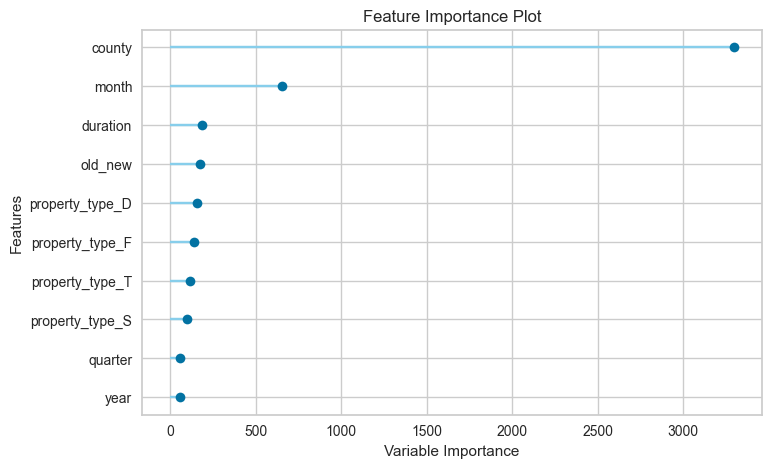

In [24]:
# Feature importance - save to file then display
plot_model(tuned_model, plot='feature', save=True)

from IPython.display import Image
Image('Feature Importance.png')

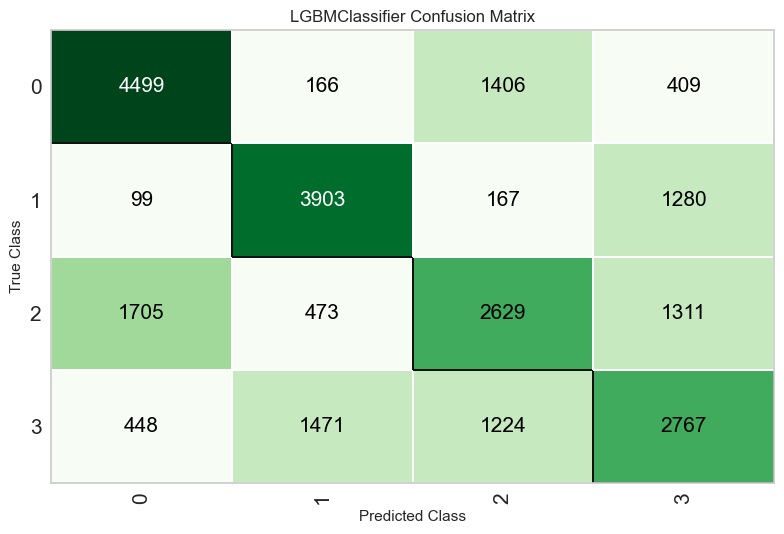

In [25]:
# Confusion matrix on held-out test set
plot_model(tuned_model, plot='confusion_matrix', save=True)

from IPython.display import Image
Image('Confusion Matrix.png')

## 8. Summary of Findings

### EDA
- Property prices are strongly right-skewed; log transformation produces an approximately normal distribution
- Detached properties command the highest median prices, with flats the lowest
- New builds carry a price premium across all property types apart from detached properties
- There is significant regional variation in median prices, with Greater London and surrounding home counties substantially above the national median

### Hypothesis Tests
| Test | Result | Key Finding |
|---|---|---|
| Kruskal-Wallis (property types) | Reject H₀ | Prices differ significantly across property types |
| Welch's t-test (2024 vs 2025) | Reject H₀ | Statistically significant price change from 2024 to 2025 |
| Mann-Whitney U (freehold vs leasehold) | Reject H₀ | Significant price premium for freehold tenure |
| Chi-squared (type vs build status) | Reject H₀ | Property type and new/established status are not independent |

### AutoML
- PyCaret compared multiple classifiers on the price band prediction task - LGBM was found to be the best performing model
- County and month emerged as the most predictive features, with county as clearly the most important
- See model comparison table above for full leaderboard